In [ ]:
!pip install scikit-learn pandas matplotlib

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv
Saving test.csv to test.csv
Saving validation.csv to validation.csv


In [2]:
import pandas as pd

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print(train_df.columns)
train_df.head()

Train: 87369
Val: 10842
Test: 10955
Index(['split', 'sent_id', 'token_id', 'token', 'lemma', 'upos', 'head',
       'deprel'],
      dtype='object')


,split,sent_id,token_id,token,lemma,upos,head,deprel
0,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,1,Доброго,добрий,ADJ,2,amod
1,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,2,ранку,ранок,NOUN,0,root
2,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,3,",",",",PUNCT,6,punct
3,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,4,шановні,шановний,ADJ,6,amod
4,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,5,народні,народний,ADJ,6,amod


In [3]:
# базовий текст (тільки токен)
train_df["text"] = train_df["token"].astype(str)
val_df["text"]   = val_df["token"].astype(str)
test_df["text"]  = test_df["token"].astype(str)

# покращений текст (token + lemma)
train_df["text2"] = train_df["token"] + " " + train_df["lemma"]
val_df["text2"]   = val_df["token"] + " " + val_df["lemma"]
test_df["text2"]  = test_df["token"] + " " + test_df["lemma"]

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipe1 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression(max_iter=300))
])

pipe1.fit(train_df["text"], train_df["upos"])

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=300))])

In [5]:
pipe2 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe2.fit(train_df["text2"], train_df["upos"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LogisticRegression(max_iter=500))])

In [6]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# baseline 1
pred1 = pipe1.predict(test_df["text"])

print("=== BASELINE 1 ===")
print("Accuracy:", accuracy_score(test_df["upos"], pred1))
print("Macro-F1:", f1_score(test_df["upos"], pred1, average="macro"))

# baseline 2
pred2 = pipe2.predict(test_df["text2"])

print("\n=== BASELINE 2 ===")
print("Accuracy:", accuracy_score(test_df["upos"], pred2))
print("Macro-F1:", f1_score(test_df["upos"], pred2, average="macro"))

print("\nClassification report:")
print(classification_report(test_df["upos"], pred2))

=== BASELINE 1 ===
Accuracy: 0.7707895937927887
Macro-F1: 0.6631182169365623

=== BASELINE 2 ===
Accuracy: 0.8216339570972159
Macro-F1: 0.694705275522238

Classification report:
              precision    recall  f1-score   support

         ADJ       0.99      0.72      0.83      1043
         ADP       1.00      0.68      0.81       928
         ADV       0.97      0.88      0.92       533
         AUX       0.90      0.69      0.78       122
       CCONJ       0.95      0.31      0.47       324
         DET       0.97      0.98      0.98       440
        INTJ       0.00      0.00      0.00         0
        NOUN       1.00      0.86      0.92      2721
         NUM       0.76      0.29      0.42       127
        PART       0.98      0.80      0.88       273
        PRON       0.99      0.76      0.86       563
       PROPN       1.00      0.60      0.75       379
       PUNCT       0.54      1.00      0.70      2092
       SCONJ       0.84      0.97      0.90       194
        VER

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

<Figure size 1000x1000 with 0 Axes>

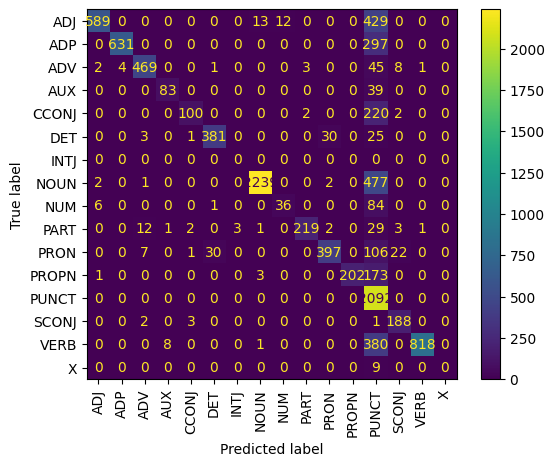

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    test_df["upos"], pred1,
    xticks_rotation=90
)
plt.show()

<Figure size 1000x1000 with 0 Axes>

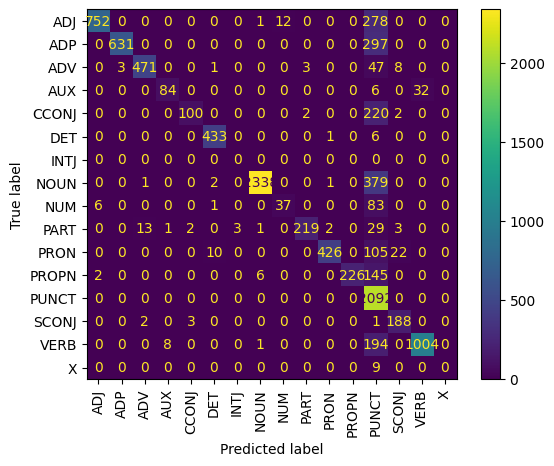

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    test_df["upos"], pred2,
    xticks_rotation=90
)
plt.show()

In [9]:
import numpy as np

vectorizer = pipe2.named_steps["tfidf"]
clf = pipe2.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
classes = clf.classes_

for i, cls in enumerate(classes):
    top10 = np.argsort(clf.coef_[i])[-10:]
    print(f"\nTop features for {cls}:")
    print(feature_names[top10])


Top features for ADJ:
['відповідний' 'національний' 'шановний' 'перший' 'український'
 'державний' 'російський' 'верховний' 'політичний' 'народний']

Top features for ADP:
['по' 'із' 'на на' 'щодо' 'від' 'на' 'за' 'для' 'про' 'до']

Top features for ADV:
['потрібно' 'тут' 'також' 'дуже' 'ще' 'вже' 'треба' 'тому' 'зараз'
 'сьогодні']

Top features for AUX:
['будуть бути' 'були' 'були бути' 'буде' 'буде бути' 'будемо'
 'будемо бути' 'би би' 'би' 'бути']

Top features for CCONJ:
['однак' 'тобто' 'або або' 'проте' 'але але' 'чи' 'та та' 'або' 'але' 'та']

Top features for DET:
['ваш' 'кожний' 'інший' 'весь' 'свій' 'такий' 'той' 'який' 'наш' 'цей']

Top features for INTJ:
['ну' 'гаразд' 'спасибі спасибі' 'ні ні' 'да да' 'так так' 'ні' 'спасибі'
 'да' 'так']

Top features for NOUN:
['людина' 'проект' 'пропозиція' 'рада' 'рішення' 'фракція' 'рік' 'питання'
 'закон' 'депутат']

Top features for NUM:
['100' '17' '10' 'ять' '14' '15' '20' 'три' 'два' 'один']

Top features for PART:
['же' 'прост

In [10]:
errors = test_df.copy()
errors["pred"] = pred2

errors = errors[errors["upos"] != errors["pred"]]

print("Кількість помилок:", len(errors))

errors[["token","lemma","upos","pred"]].head(10)

Кількість помилок: 1954


,token,lemma,upos,pred
2,116,116,NUM,PUNCT
7,І,і,CCONJ,PUNCT
10,41-а,41-й,ADJ,PUNCT
15,секундочку,секундочка,NOUN,PUNCT
17,41-а,41-й,ADJ,PUNCT
21,Чорний,Чорний,PROPN,ADJ
29,я,я,PRON,PUNCT
39,і,і,CCONJ,PUNCT
43,поправок,поправка,NOUN,PUNCT
46,в,в,ADP,PUNCT


In [11]:
errors.head(20).to_json("error_cases_lab6.jsonl", orient="records", lines=True)

In [12]:
acc1 = accuracy_score(test_df["upos"], pred1)
f1_1 = f1_score(test_df["upos"], pred1, average="macro")

acc2 = accuracy_score(test_df["upos"], pred2)
f1_2 = f1_score(test_df["upos"], pred2, average="macro")

summary = f"""
# Lab 6 Summary

Baseline 1:
Accuracy: {acc1:.4f}
Macro-F1: {f1_1:.4f}

Baseline 2:
Accuracy: {acc2:.4f}
Macro-F1: {f1_2:.4f}

Висновок:
Baseline 2 працює краще завдяки використанню bigrams і lemma.
"""

with open("audit_summary_lab6.md", "w") as f:
    f.write(summary)

print("✅ audit_summary_lab6.md створено")

✅ audit_summary_lab6.md створено


In [14]:
import json
import random
from collections import Counter

# Шлях до твого JSONL файлу з результатами
file_path = "error_cases_lab6.jsonl"

# Зчитування всіх записів
data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))

# Фільтруємо тільки помилки (pred != upos)
errors = [d for d in data if d["pred"] != d["upos"]]

print(f"Total errors: {len(errors)}\n")

# Виводимо 10 випадкових прикладів
print("=== 10 Random Error Examples ===")
for e in random.sample(errors, min(10, len(errors))):
    print(f"Token: {e['token']}\tTrue: {e['upos']}\tPred: {e['pred']}\tText snippet: {e.get('text2','-')}")

# Рахуємо топ-5 найчастіших mispredictions
miscounts = Counter(f"{e['upos']} → {e['pred']}" for e in errors)
print("\n=== Top 5 Most Frequent Mispredictions ===")
for mis, count in miscounts.most_common(5):
    print(f"{mis}: {count} cases")

Total errors: 20

=== 10 Random Error Examples ===
Token: Маркет	True: NOUN	Pred: PUNCT	Text snippet: Маркет маркет
Token: AliExpress	True: X	Pred: PUNCT	Text snippet: AliExpress AliExpress
Token: 41-а	True: ADJ	Pred: PUNCT	Text snippet: 41-а 41-й
Token: замовляти	True: VERB	Pred: PUNCT	Text snippet: замовляти замовляти
Token: Я	True: PRON	Pred: PUNCT	Text snippet: Я я
Token: секундочку	True: NOUN	Pred: PUNCT	Text snippet: секундочку секундочка
Token: в	True: ADP	Pred: PUNCT	Text snippet: в в
Token: замовляла	True: VERB	Pred: PUNCT	Text snippet: замовляла замовляти
Token: І	True: CCONJ	Pred: PUNCT	Text snippet: І і
Token: поправок	True: NOUN	Pred: PUNCT	Text snippet: поправок поправка

=== Top 5 Most Frequent Mispredictions ===
NOUN → PUNCT: 5 cases
ADJ → PUNCT: 3 cases
VERB → PUNCT: 3 cases
CCONJ → PUNCT: 2 cases
PRON → PUNCT: 2 cases
